In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
import warnings
warnings.filterwarnings('ignore')

In [90]:
# ─────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────
df = pd.read_csv("netflix.csv")
print(df.head())
print(df.shape)
print(df.dtypes)

  show_id     type  title           director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie   7:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

          date_added  release_year rating   duration  \
0    August 14, 2020          2020  TV-MA  4 Seasons   
1  December 23, 2016          2016  TV-MA     93 min   
2  December 20, 2018          2011      R     78 min   
3  November 16, 2017          2009  PG-13     80 min   
4   

In [91]:
# ─────────────────────────────────────────
# 2. CLEAN — handle nulls & duplicates FIRST
# (before any encoding)
# ─────────────────────────────────────────
# Fill missing country with mode
df['country'] = df['country'].fillna(df['country'].mode()[0])
 
# Fill missing director with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
 
# Fill missing cast with 'Unknown'
df['cast'] = df['cast'].fillna('Unknown')
 
# Drop rows where date_added is missing
df = df.dropna(subset=['date_added'])
df = df.dropna(subset=['rating'])
 
# Drop duplicates
df.drop_duplicates(inplace=True)
 
print("\nNull counts after cleaning:")
print(df.isnull().sum())


Null counts after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [113]:
# ─────────────────────────────────────────
# 3. FEATURE ENGINEERING
# ─────────────────────────────────────────
# Extract year from date_added
df['year_added'] = pd.to_datetime(df['date_added'].str.strip(),
                                  format='%B %d, %Y').dt.year
 
# Extract numeric duration
# Movies → minutes, TV Shows → number of seasons
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(int)

In [92]:
# ─────────────────────────────────────────
# 4. ENCODE BINARY TARGET
# ─────────────────────────────────────────
df.rename(columns={'type':"is_movie"},inplace=True)
df['is_movie'] = df['is_movie'].map({"Movie": 1, "TV Show": 0})


In [93]:
# ─────────────────────────────────────────
# 5. ONE-HOT ENCODE 'rating'
# ─────────────────────────────────────────
df = pd.get_dummies(data=df, columns=['rating'])
 
# Cast only the new bool dummy columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
 
print("\nColumns after encoding:")
print(df.columns.tolist())


Columns after encoding:
['show_id', 'is_movie', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'duration', 'listed_in', 'description', 'rating_G', 'rating_NC-17', 'rating_NR', 'rating_PG', 'rating_PG-13', 'rating_R', 'rating_TV-14', 'rating_TV-G', 'rating_TV-MA', 'rating_TV-PG', 'rating_TV-Y', 'rating_TV-Y7', 'rating_TV-Y7-FV', 'rating_UR']


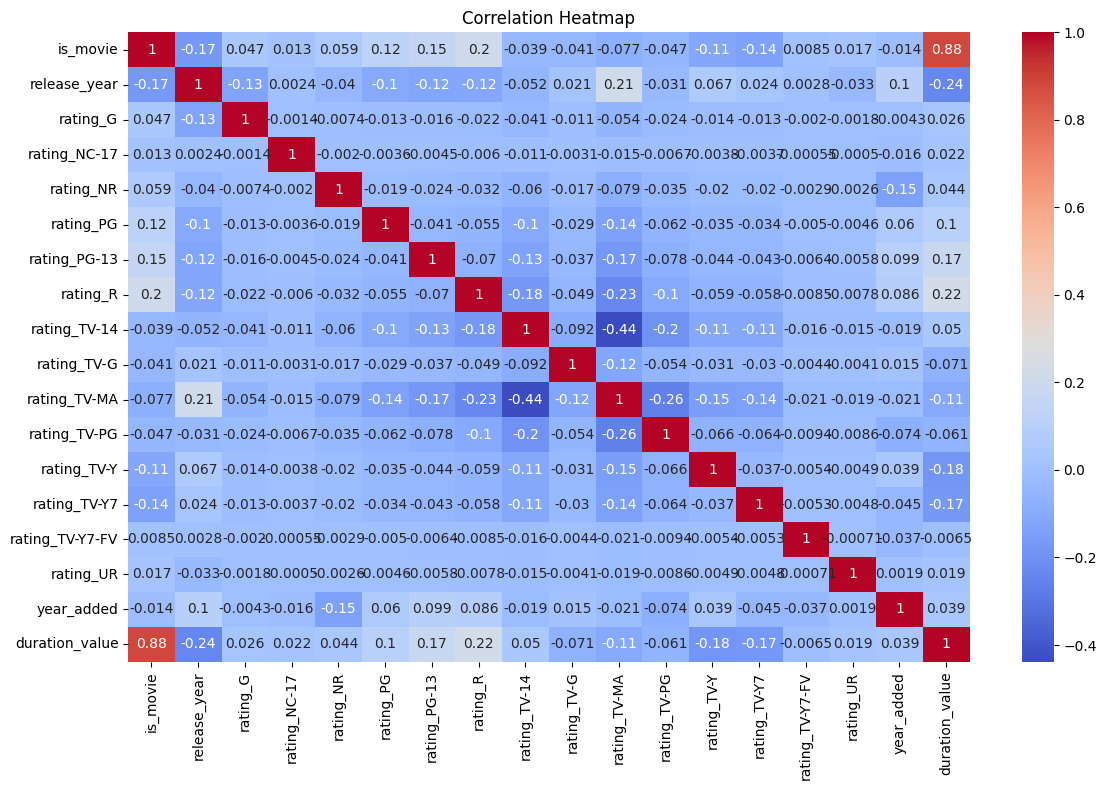

In [115]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

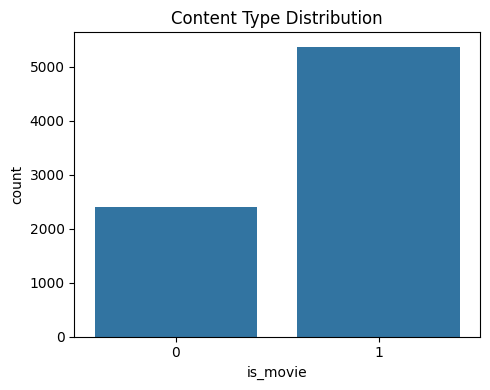

In [95]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='is_movie')
plt.title('Content Type Distribution')
plt.tight_layout()
plt.show()

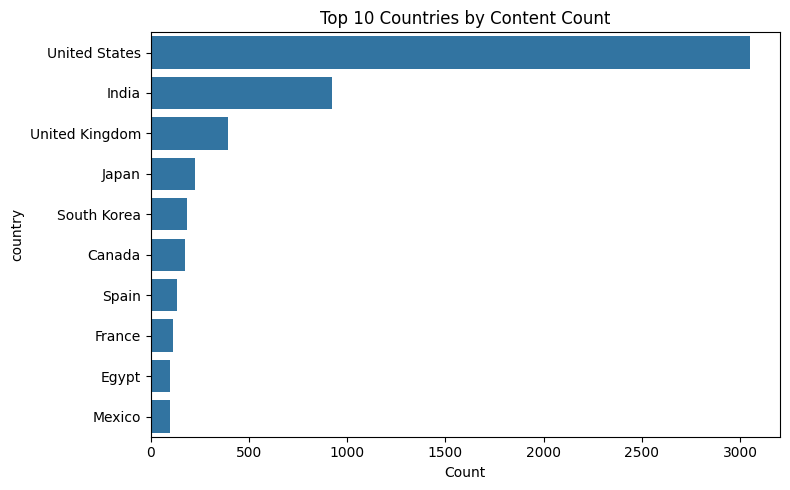

In [96]:
# Top 10 countries (correct barplot usage)
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(8, 5))
sns.barplot(y=top_countries.index, x=top_countries.values)
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

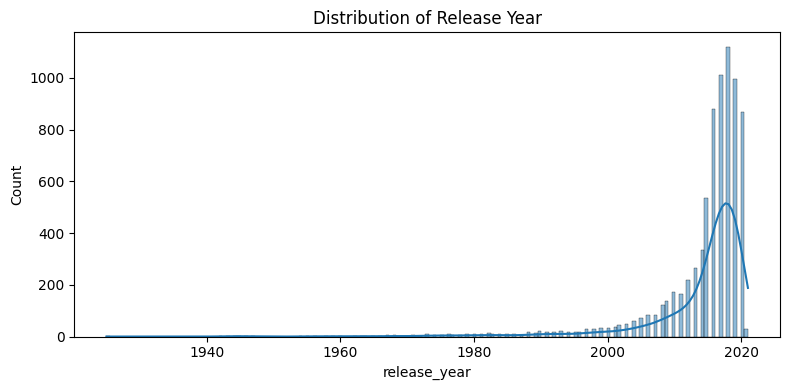

In [97]:
# Distribution of release_year
plt.figure(figsize=(8, 4))
sns.histplot(df['release_year'], kde=True)
plt.title('Distribution of Release Year')
plt.tight_layout()
plt.show()
 

In [103]:
df.describe()

,is_movie,release_year,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
count,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000,7770.000000
mean,0.691377,2013.935393,0.005019,0.000386,0.010682,0.031789,0.049678,0.085586,0.248134,0.024968,0.368211,0.103475,0.035907,0.034749,0.000772,0.000644
std,0.461955,8.764357,0.070674,0.019647,0.102807,0.175449,0.217293,0.279769,0.431958,0.156037,0.482350,0.304598,0.186071,0.183155,0.027780,0.025361
min,0.000000,1925.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2013.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,2017.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,2018.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [104]:
# ─────────────────────────────────────────
# 8. STATISTICAL TESTS (before scaling)
# ─────────────────────────────────────────
from scipy.stats import pearsonr

# Define numeric features (exclude target)
numeric_features = ["release_year","rating_G","rating_NC-17","rating_NR","rating_PG","rating_PG-13","rating_R","rating_TV-14","rating_TV-G","rating_TV-MA","rating_TV-PG","rating_TV-Y","rating_TV-Y7","rating_TV-Y7-FV","rating_UR"]
 
# --- Pearson Correlation ---
correlations = {
    feature: pearsonr(df[feature], df['is_movie'])[0]
    for feature in numeric_features
}
correlation_df = pd.DataFrame(
    list(correlations.items()), columns=['Feature', 'Pearson Correlation']
)
correlation_df = correlation_df.sort_values(by='Pearson Correlation', ascending=False)
print("\nPearson Correlation with is_movie:\n", correlation_df)


Pearson Correlation with is_movie:
             Feature  Pearson Correlation
6          rating_R             0.202410
5      rating_PG-13             0.152758
4         rating_PG             0.121062
3         rating_NR             0.058584
1          rating_G             0.047454
14        rating_UR             0.016954
2      rating_NC-17             0.013131
13  rating_TV-Y7-FV             0.008543
7      rating_TV-14            -0.039332
8       rating_TV-G            -0.041298
10     rating_TV-PG            -0.046531
9      rating_TV-MA            -0.076846
11      rating_TV-Y            -0.113649
12     rating_TV-Y7            -0.139461
0      release_year            -0.173708


In [109]:

from scipy.stats import chi2_contingency
cat_features = ["rating_G","rating_NC-17","rating_NR","rating_PG","rating_PG-13","rating_R","rating_TV-14","rating_TV-G","rating_TV-MA","rating_TV-PG","rating_TV-Y","rating_TV-Y7","rating_TV-Y7-FV","rating_UR"]
 
alpha = 0.05
chi2_results = {}
 
for col in cat_features:
    contingency = pd.crosstab(df[col], df['is_movie'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = (
        'Reject Null (Keep Feature)' if p_val < alpha
        else 'Accept Null (Drop Feature)'
    )
    chi2_results[col] = {
        'chi2_statistic': round(chi2_stat, 4),
        'p_value': round(p_val, 4),
        'Decision': decision
    }
 
chi2_df = pd.DataFrame(chi2_results).T.sort_values(by='p_value')
print("\nChi-Square Results:\n", chi2_df)
 


Chi-Square Results:
                 chi2_statistic p_value                    Decision
rating_NR               25.448     0.0  Reject Null (Keep Feature)
rating_PG             112.3891     0.0  Reject Null (Keep Feature)
rating_PG-13          179.7946     0.0  Reject Null (Keep Feature)
rating_R              316.7717     0.0  Reject Null (Keep Feature)
rating_TV-MA           45.5401     0.0  Reject Null (Keep Feature)
rating_TV-PG           16.4943     0.0  Reject Null (Keep Feature)
rating_TV-Y            99.0398     0.0  Reject Null (Keep Feature)
rating_TV-Y7          149.4769     0.0  Reject Null (Keep Feature)
rating_G               16.0735  0.0001  Reject Null (Keep Feature)
rating_TV-G            12.6852  0.0004  Reject Null (Keep Feature)
rating_TV-14           11.8239  0.0006  Reject Null (Keep Feature)
rating_UR               1.0205  0.3124  Accept Null (Drop Feature)
rating_NC-17            0.2834  0.5945  Accept Null (Drop Feature)
rating_TV-Y7-FV         0.0967  0.7558  

In [114]:
# from sklearn.preprocessing import StandardScaler

# # Scale continuous columns AFTER statistical tests
# scale_cols = ['release_year', 'year_added', 'duration_value']
# scaler = StandardScaler()
# df[scale_cols] = scaler.fit_transform(df[scale_cols])

# print("\nAfter scaling:")
# print(df[scale_cols].head())

from sklearn.preprocessing import StandardScaler
cols = ['release_year', 'year_added', 'duration_value']
scaler=StandardScaler()
df[cols]=scaler.fit_transform(df[cols])